## Подготовка данных и цикл обучения

In [1]:
!python --version

Python 3.12.12


### Импорты, seed и устройство

In [2]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


In [5]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

### Данные и DataLoader

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

100%|██████████| 562M/562M [00:06<00:00, 90.6MB/s]


In [7]:
class_names = train_full.classes
print("classes:", class_names)
print("num classes:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
num classes: 47
train size: 112800
test size: 18800


In [8]:
BATCH_SIZE = 256 if DEVICE.type == "cuda" else 64

NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

In [9]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda")
)

In [10]:
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype, f"| min: {x_batch.min()}, max: {x_batch.max()}")
print("y_batch:", y_batch.shape, y_batch.dtype, f"| min: {y_batch.min()}, max: {y_batch.max()}")

x_batch: torch.Size([256, 1, 28, 28]) torch.float32 | min: -1.0, max: 1.0
y_batch: torch.Size([256]) torch.int64 | min: 0, max: 46


### Модель MLP и цикл обучения

In [11]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MLP().to(DEVICE)
print(model)
print("Trainable params:", count_params(model))

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=47, bias=True)
  )
)
Trainable params: 239919


In [12]:
class EarlyStopping:
    def __init__(self, patience: int = 3, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [13]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [15]:
def fit(model, train_loader, val_loader, optimizer, criterion, epochs=6, early_stopping=None, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [16]:
def plot_history(history, title="", filepath=""):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(epochs, history["train_loss"], label="train loss")
    ax1.plot(epochs, history["val_loss"], label="val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(title + " | Loss")
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, history["train_acc"], label="train acc")
    ax2.plot(epochs, history["val_acc"], label="val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(title + " | Accuracy")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    if filepath != "":
        plt.savefig(filepath)

In [17]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 6

In [18]:
def make_model(dropout_p: float = 0.0, use_batchnorm: bool = False):
    return MLP(dropout_p=dropout_p, use_batchnorm=use_batchnorm).to(DEVICE)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

In [19]:
def run_experiment(exp_id, optimizer_kind, lr, dropout_p=0.0, use_batchnorm=False, weight_decay=0.0, momentum=0.9, early_stopping=None, epochs=EPOCHS, return_model=False):
    model = make_model(dropout_p=dropout_p, use_batchnorm=use_batchnorm)
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    history = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, early_stopping=early_stopping, verbose=True)

    best_val_acc = float(np.nanmax(history["val_acc"])) if len(history["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(history["val_loss"])) if len(history["val_loss"]) else float("nan")

    return {
        "experiment_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "dropout_p": dropout_p,
        "use_batchnorm": use_batchnorm,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else 0,
        "epochs_trained": len(history["val_acc"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": history,
        "model": model if return_model else None,
    }

## Эксперименты

In [20]:
results = []

### Часть A: регуляризация и переобучение

#### E1 (base)

Epoch 01/6 | train loss 1.4071, acc 0.605 | val loss 0.9527, acc 0.725 | 20.7s
Epoch 02/6 | train loss 0.8101, acc 0.753 | val loss 0.7195, acc 0.781 | 19.5s
Epoch 03/6 | train loss 0.6552, acc 0.793 | val loss 0.6306, acc 0.803 | 19.4s
Epoch 04/6 | train loss 0.5699, acc 0.816 | val loss 0.5836, acc 0.817 | 19.5s
Epoch 05/6 | train loss 0.5215, acc 0.828 | val loss 0.5431, acc 0.825 | 19.6s
Epoch 06/6 | train loss 0.4880, acc 0.836 | val loss 0.5510, acc 0.824 | 19.3s


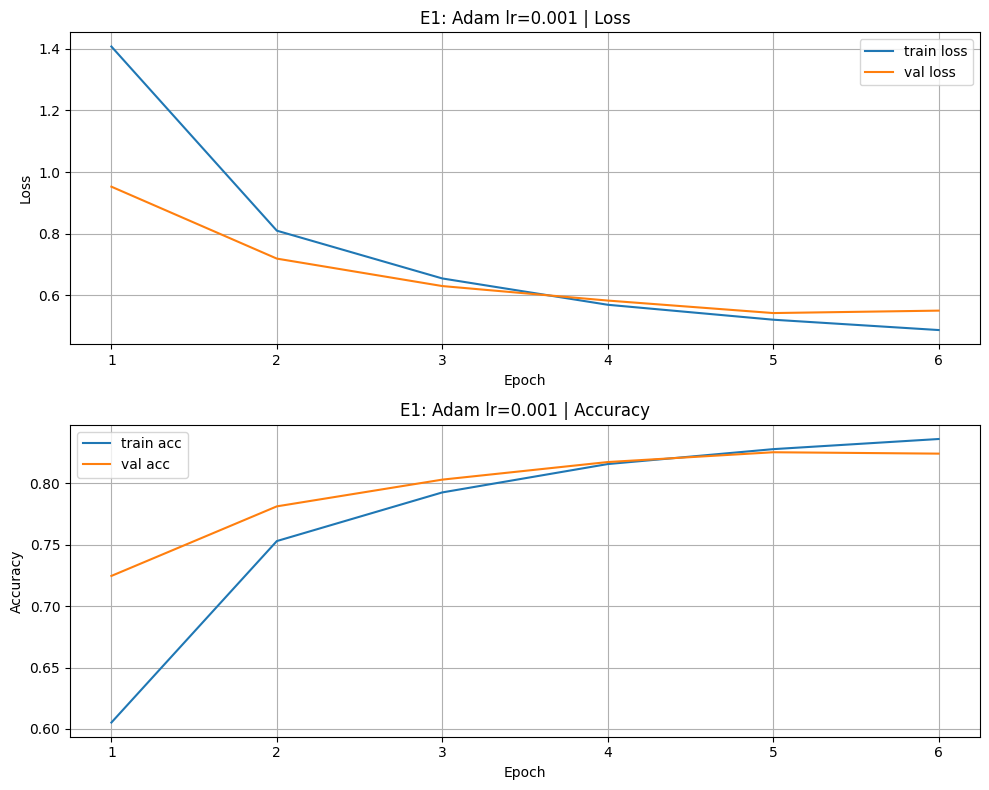

In [21]:
exp_id = "E1"
res_e1 = run_experiment(exp_id, "Adam", 1e-3)
results.append(res_e1)
plot_history(res_e1["history"], title=f"{exp_id}: Adam lr={res_e1["lr"]}")

#### E2 (Dropout)

Epoch 01/6 | train loss 1.6126, acc 0.540 | val loss 0.9275, acc 0.727 | 19.4s
Epoch 02/6 | train loss 0.9696, acc 0.704 | val loss 0.7170, acc 0.783 | 19.5s
Epoch 03/6 | train loss 0.8224, acc 0.743 | val loss 0.6366, acc 0.803 | 19.4s
Epoch 04/6 | train loss 0.7465, acc 0.762 | val loss 0.6014, acc 0.810 | 19.5s
Epoch 05/6 | train loss 0.6958, acc 0.775 | val loss 0.5572, acc 0.825 | 19.2s
Epoch 06/6 | train loss 0.6681, acc 0.782 | val loss 0.5330, acc 0.829 | 19.2s


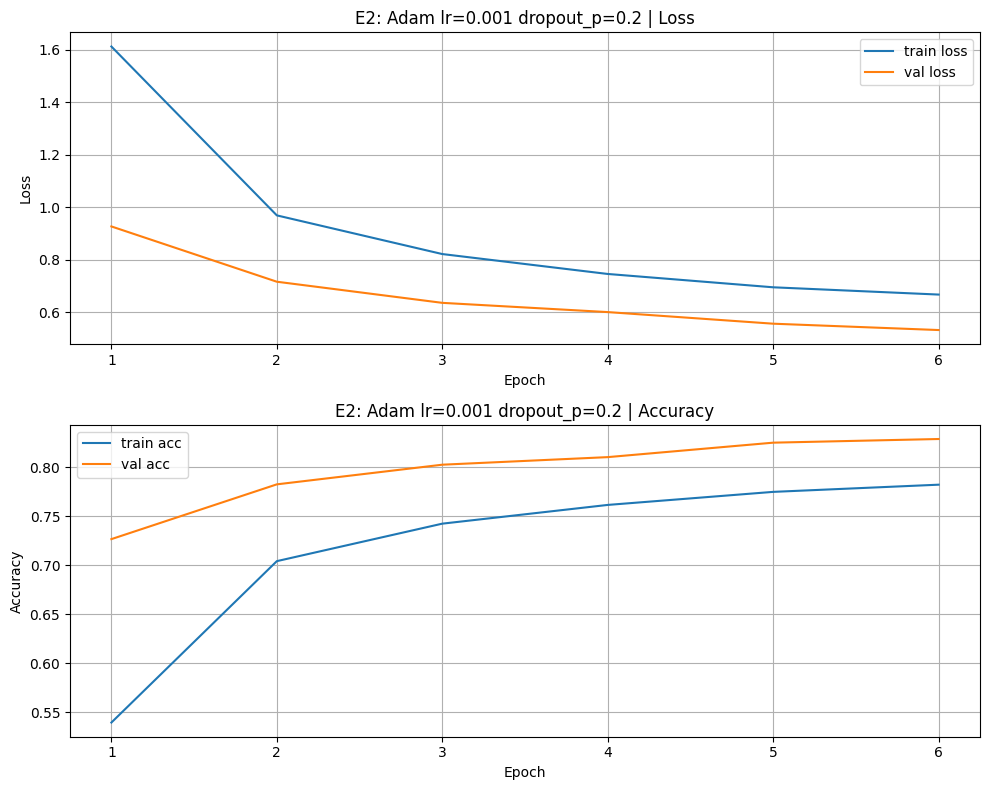

In [22]:
exp_id = "E2"
res_e2 = run_experiment(exp_id, "Adam", 1e-3, dropout_p=0.2)
results.append(res_e2)
plot_history(res_e2["history"], title=f"{exp_id}: Adam lr={res_e2["lr"]} dropout_p={res_e2["dropout_p"]}")

#### E3 (BatchNorm)

Epoch 01/6 | train loss 1.0798, acc 0.722 | val loss 0.6187, acc 0.813 | 19.7s
Epoch 02/6 | train loss 0.5330, acc 0.826 | val loss 0.5192, acc 0.831 | 19.9s
Epoch 03/6 | train loss 0.4450, acc 0.849 | val loss 0.4807, acc 0.839 | 19.4s
Epoch 04/6 | train loss 0.3996, acc 0.861 | val loss 0.4774, acc 0.847 | 20.4s
Epoch 05/6 | train loss 0.3633, acc 0.871 | val loss 0.4520, acc 0.852 | 19.2s
Epoch 06/6 | train loss 0.3375, acc 0.878 | val loss 0.4649, acc 0.848 | 20.5s


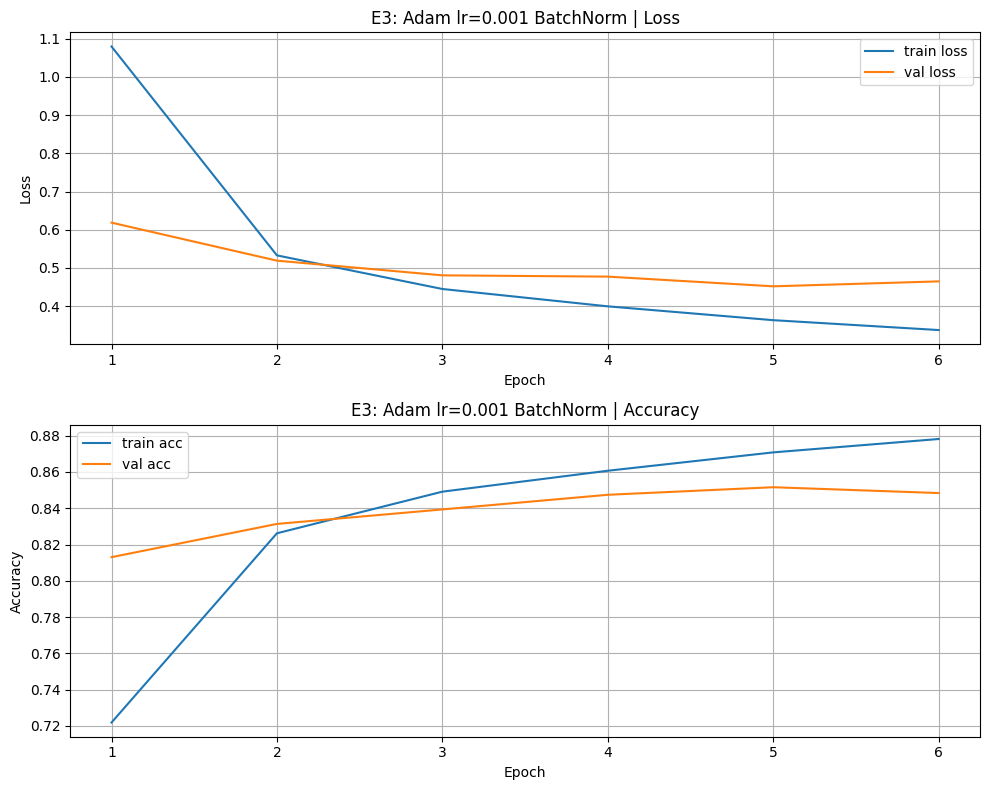

In [23]:
exp_id = "E3"
res_e3 = run_experiment(exp_id, "Adam", 1e-3, use_batchnorm=True)
results.append(res_e3)
plot_history(res_e3["history"], title=f"{exp_id}: Adam lr={res_e3["lr"]} BatchNorm")

#### E4 (EarlyStopping)

Epoch 01/10 | train loss 1.0863, acc 0.723 | val loss 0.6502, acc 0.799 | 19.0s
Epoch 02/10 | train loss 0.5338, acc 0.827 | val loss 0.5263, acc 0.830 | 19.8s
Epoch 03/10 | train loss 0.4446, acc 0.849 | val loss 0.4943, acc 0.837 | 18.8s
Epoch 04/10 | train loss 0.3956, acc 0.862 | val loss 0.4780, acc 0.844 | 20.0s
Epoch 05/10 | train loss 0.3621, acc 0.871 | val loss 0.4716, acc 0.845 | 19.0s
Epoch 06/10 | train loss 0.3376, acc 0.878 | val loss 0.4570, acc 0.851 | 20.0s
Epoch 07/10 | train loss 0.3140, acc 0.885 | val loss 0.4532, acc 0.849 | 18.8s
Epoch 08/10 | train loss 0.2951, acc 0.891 | val loss 0.4674, acc 0.849 | 20.2s
Epoch 09/10 | train loss 0.2822, acc 0.894 | val loss 0.4594, acc 0.848 | 19.5s
EarlyStopping: остановка на эпохе 9. Лучший val_acc=0.8505


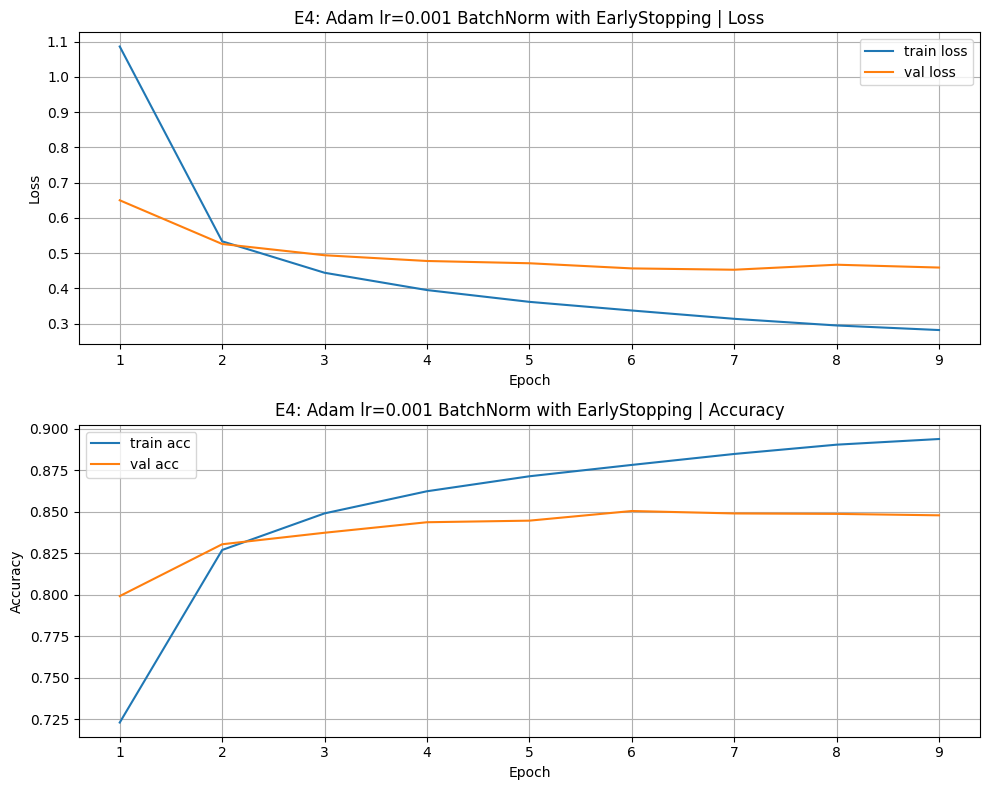

<Figure size 640x480 with 0 Axes>

In [25]:
exp_id = "E4"

if res_e3["best_val_accuracy"] >= res_e2["best_val_accuracy"]:
    res_e4 = run_experiment(exp_id, "Adam", 1e-3, use_batchnorm=True, early_stopping=EarlyStopping(), epochs=10, return_model=True)
    plot_history(res_e4["history"], title=f"{exp_id}: Adam lr={res_e4["lr"]} BatchNorm with EarlyStopping",
                 filepath="artifacts/figures/curves_best.png")
else:
    res_e4 = run_experiment(exp_id, "Adam", 1e-3, dropout_p=0.2, early_stopping=EarlyStopping(), epochs=10, return_model=True)
    plot_history(res_e4["history"], title=f"{exp_id}: Adam lr={res_e4["lr"]} dropout_p={res_e4["dropout_p"]} with EarlyStopping",
                 filepath="artifacts/figures/curves_best.png")

results.append(res_e4)

In [26]:
best_model = res_e4["model"]
tmp_path = 'best_model.pt'
torch.save(best_model.state_dict(), tmp_path)
print('saved to', tmp_path, 'size:', os.path.getsize(tmp_path), 'bytes')

saved to best_model.pt size: 971765 bytes


In [27]:
best_model

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=47, bias=True)
  )
)

In [28]:
best_config = {
    "dataset": "EMNIST",
    "seed": SEED,
    "model_architecture": [str(best_model.net[i]) for i in range(len(best_model.net))],
    "model_config": {
        "dropout_p": results[3]["dropout_p"],
        "use_batchnorm": results[3]["use_batchnorm"],
    },
    "optimizer": results[3]["optimizer"],
    "lr": results[3]["lr"],
}

with open("artifacts/best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

In [29]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion)
print("test loss:", test_loss)
print("test accuracy:", test_acc)

test loss: 0.481464856782475
test accuracy: 0.843259833954476


### Часть B: LR, оптимизаторы, weight decay

#### O1 (LR слишком большой)

Epoch 01/6 | train loss 1.0023, acc 0.696 | val loss 0.8718, acc 0.742 | 19.1s
Epoch 02/6 | train loss 0.6763, acc 0.779 | val loss 0.6489, acc 0.791 | 20.2s
Epoch 03/6 | train loss 0.6074, acc 0.798 | val loss 0.6501, acc 0.791 | 19.1s
Epoch 04/6 | train loss 0.5657, acc 0.809 | val loss 0.6394, acc 0.797 | 20.1s
Epoch 05/6 | train loss 0.5422, acc 0.815 | val loss 0.6116, acc 0.809 | 19.2s
Epoch 06/6 | train loss 0.5195, acc 0.823 | val loss 0.6063, acc 0.805 | 20.2s


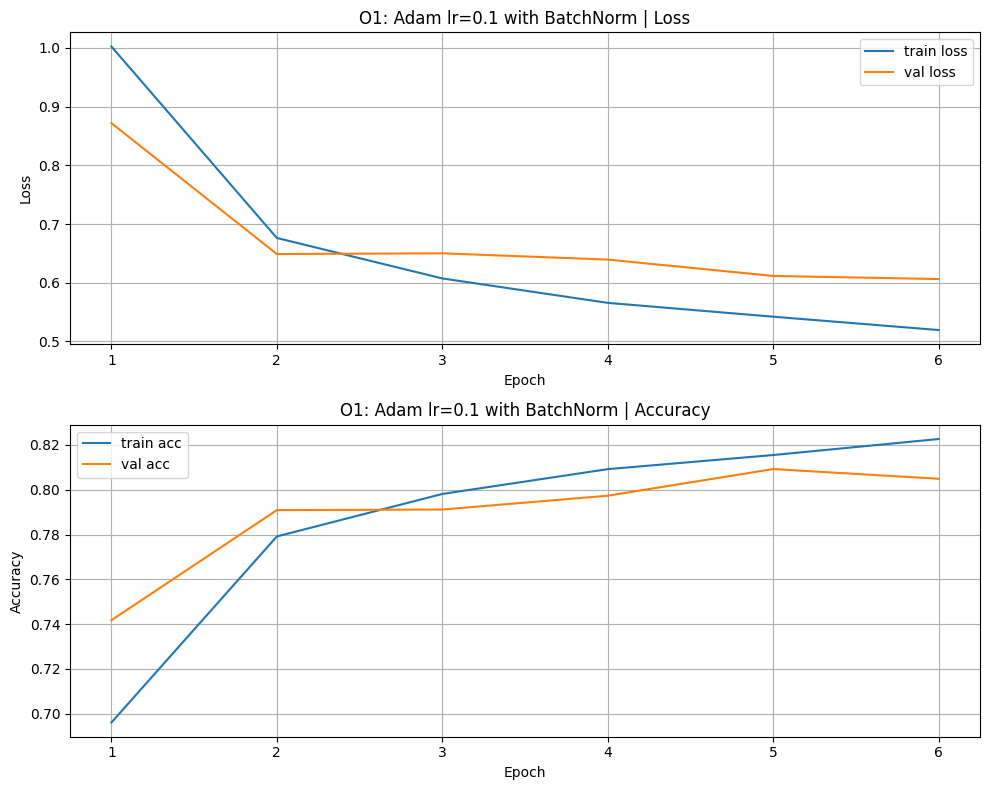

In [30]:
exp_id = "O1"
res_o1 = run_experiment(exp_id, "Adam", 1e-1, use_batchnorm=True)
results.append(res_o1)
plot_history(res_o1["history"], title=f"{exp_id}: Adam lr={res_o1["lr"]} with BatchNorm")

#### O2 (LR слишком маленький)

Epoch 01/6 | train loss 3.5889, acc 0.128 | val loss 3.3025, acc 0.262 | 19.5s
Epoch 02/6 | train loss 3.1063, acc 0.353 | val loss 2.9388, acc 0.424 | 21.6s
Epoch 03/6 | train loss 2.8067, acc 0.466 | val loss 2.6899, acc 0.501 | 21.4s
Epoch 04/6 | train loss 2.5835, acc 0.528 | val loss 2.4928, acc 0.549 | 20.1s
Epoch 05/6 | train loss 2.4021, acc 0.568 | val loss 2.3188, acc 0.582 | 20.8s
Epoch 06/6 | train loss 2.2471, acc 0.595 | val loss 2.1779, acc 0.608 | 19.2s


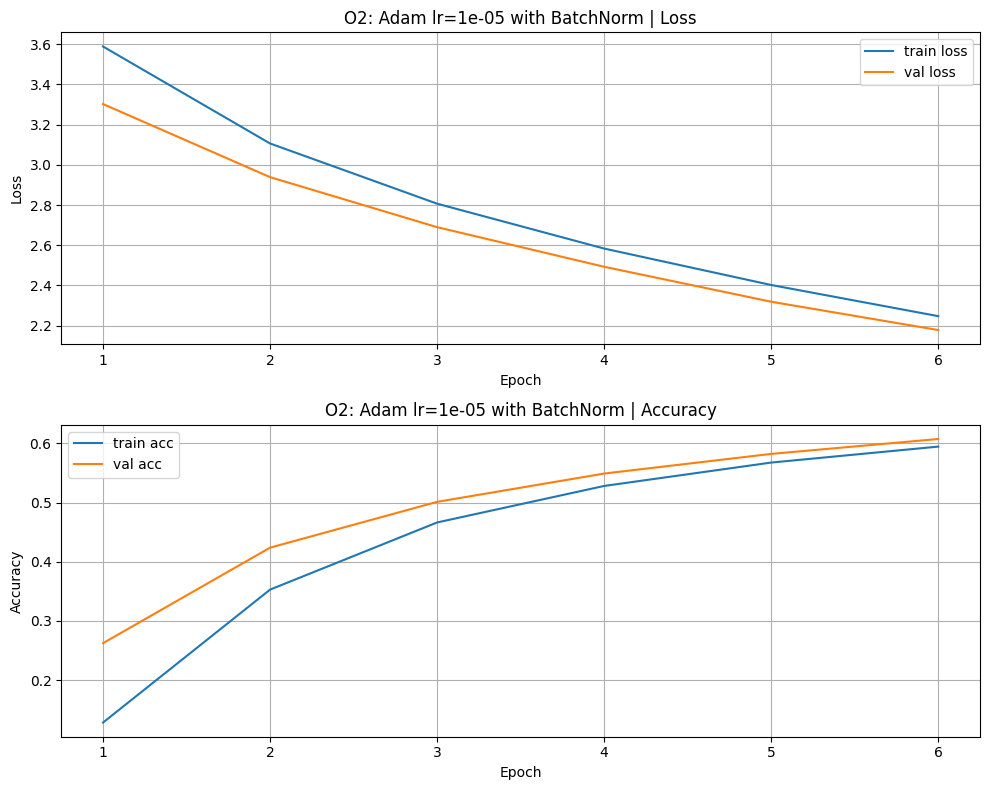

In [31]:
exp_id = "O2"
res_o2 = run_experiment(exp_id, "Adam", 1e-5, use_batchnorm=True)
results.append(res_o2)
plot_history(res_o2["history"], title=f"{exp_id}: Adam lr={res_o2["lr"]} with BatchNorm")

#### O3 (SGD + momentum + weight decay)

Epoch 01/12 | train loss 2.8093, acc 0.402 | val loss 2.1530, acc 0.558 | 20.4s
Epoch 02/12 | train loss 1.8126, acc 0.615 | val loss 1.5354, acc 0.654 | 19.4s
Epoch 03/12 | train loss 1.3615, acc 0.684 | val loss 1.2217, acc 0.703 | 20.5s
Epoch 04/12 | train loss 1.1143, acc 0.722 | val loss 1.0361, acc 0.737 | 19.0s
Epoch 05/12 | train loss 0.9598, acc 0.749 | val loss 0.9134, acc 0.760 | 20.2s
Epoch 06/12 | train loss 0.8529, acc 0.770 | val loss 0.8262, acc 0.777 | 19.0s
Epoch 07/12 | train loss 0.7754, acc 0.785 | val loss 0.7671, acc 0.788 | 20.2s
Epoch 08/12 | train loss 0.7163, acc 0.798 | val loss 0.7149, acc 0.798 | 19.5s
Epoch 09/12 | train loss 0.6674, acc 0.807 | val loss 0.6790, acc 0.803 | 19.8s
Epoch 10/12 | train loss 0.6293, acc 0.817 | val loss 0.6487, acc 0.810 | 19.7s
Epoch 11/12 | train loss 0.5962, acc 0.825 | val loss 0.6239, acc 0.818 | 19.7s
Epoch 12/12 | train loss 0.5688, acc 0.830 | val loss 0.6034, acc 0.822 | 19.8s


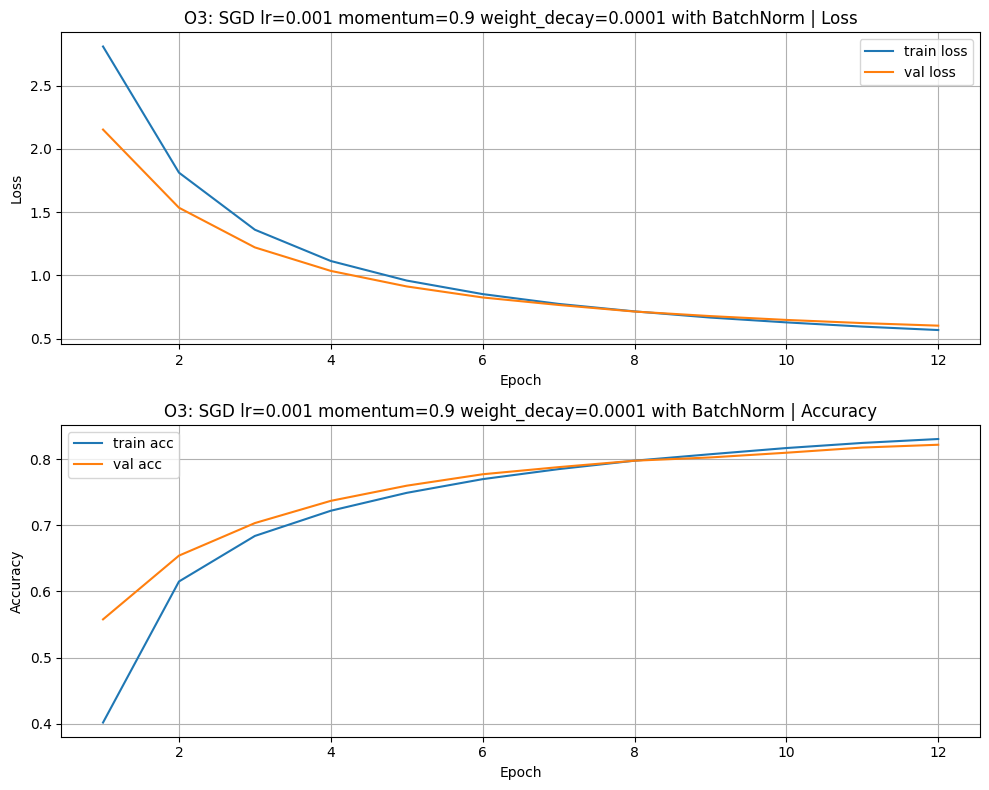

In [32]:
exp_id = "O3"
res_o3 = run_experiment(exp_id, "SGD", 1e-3, use_batchnorm=True, momentum=0.9, weight_decay=1e-4, epochs=12)
results.append(res_o3)
plot_history(res_o3["history"], title=f"{exp_id}: SGD lr={res_o3["lr"]} momentum={res_o3["momentum"]} weight_decay={res_o3["weight_decay"]} with BatchNorm")

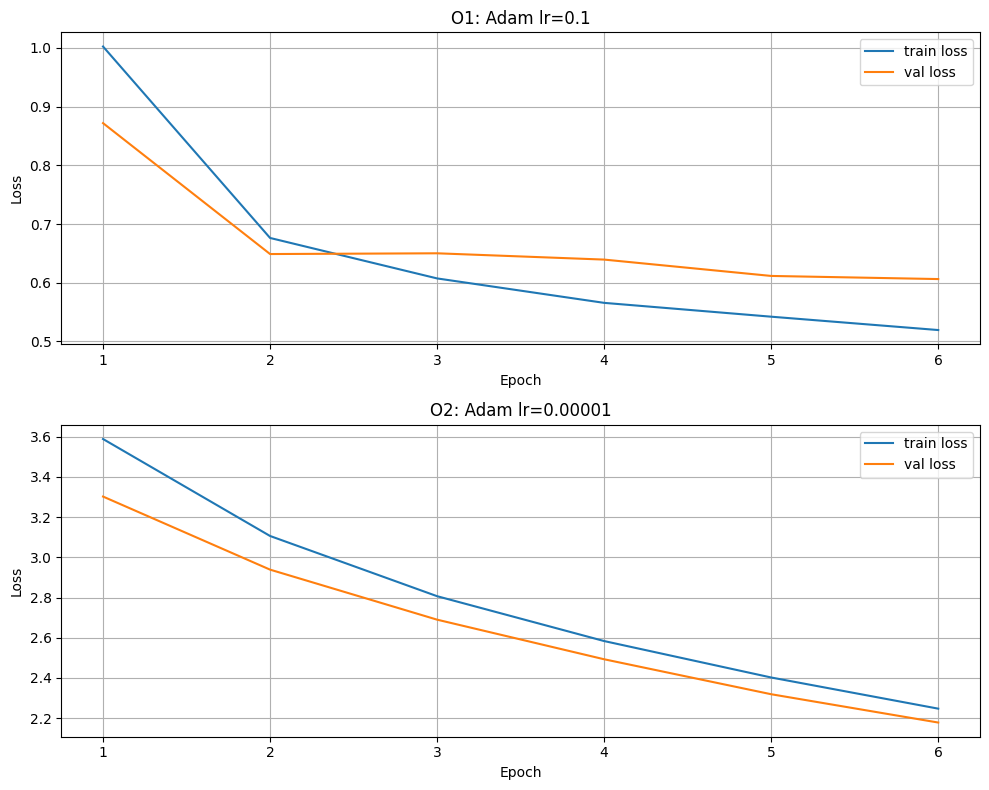

<Figure size 640x480 with 0 Axes>

In [34]:
def plot_o1_o2_losses():
    hist_o1 = res_o1["history"]
    hist_o2 = res_o2["history"]

    epochs = list(range(1, len(hist_o1["train_loss"]) + 1))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(epochs, hist_o1["train_loss"], label="train loss")
    ax1.plot(epochs, hist_o1["val_loss"], label="val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("O1: Adam lr=0.1")
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, hist_o2["train_loss"], label="train loss")
    ax2.plot(epochs, hist_o2["val_loss"], label="val loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.set_title("O2: Adam lr=0.00001")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig("artifacts/figures/curves_lr_extremes.png")

plot_o1_o2_losses()

In [35]:
df = pd.DataFrame(results, columns=["experiment_id", "optimizer", "lr", "weight_decay", "momentum", "epochs_trained", "best_val_accuracy", "best_val_loss"])

df['dataset'] = "EMNIST"
df['seed'] = SEED
df['model_summary'] = [f"hidden_dims=(256,128) | activation=ReLU | dropout_p={res["dropout_p"]} | use_batchnorm={res["use_batchnorm"]}" for res in results]

df.to_csv("artifacts/runs.csv", index=False)